# Mobile Money Loan Eligibility and Loan Amount Prediction

## Hybrid Machine Learning Project: Supervised and Unsupervised Learning

### Project Theme
This notebook develops a machine learning system that predicts:

1. Whether a mobile money customer is eligible for a loan.
2. The loan amount or loan limit the customer may qualify for.
3. The customer risk group using unsupervised clustering.

The project is inspired by mobile money credit services such as MoKash, where customer transaction behavior can be used to estimate creditworthiness.

---

## Research Problem

Mobile money loan providers need reliable ways to decide whether a customer should receive a loan and how much should be given. A poor decision may lead to financial loss if risky customers are approved. A very strict system may also reject good customers.

This project uses both supervised and unsupervised machine learning to support loan decision-making.

---

## Machine Learning Methods Used

### Unsupervised Learning
Used for customer segmentation and risk grouping.

1. K-Means Clustering
2. Gaussian Mixture Model
3. Agglomerative Clustering

### Supervised Learning for Loan Eligibility
Used to predict whether a customer qualifies for a loan.

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Gradient Boosting Classifier
5. Support Vector Machine
6. K-Nearest Neighbors Classifier

### Supervised Learning for Loan Amount Prediction
Used to predict the amount a customer is eligible to borrow.

1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor
4. Random Forest Regressor
5. Gradient Boosting Regressor
6. K-Nearest Neighbors Regressor

---

## Important Note

If the dataset does not contain real loan approval and repayment labels, this notebook creates simulated academic targets using transparent financial rules. This is acceptable for coursework, but the limitation must be stated clearly in the report.

# 1. Import Required Libraries

In [11]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

# 2. Load Dataset

Place your dataset in the same folder as this notebook and name it:

```text
assignment_dataset.csv
```

The notebook is designed for a mobile money transaction dataset with columns such as:

- `step`
- `type`
- `amount`
- `nameOrig`
- `oldbalanceOrg`
- `newbalanceOrig`
- `nameDest`
- `oldbalanceDest`
- `newbalanceDest`

If your dataset has extra columns such as `isFraud` or `isFlaggedFraud`, they will be removed because this project is about loan eligibility, not fraud detection.

In [12]:
DATA_PATH = "assignment_dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "assignment_dataset.csv was not found. "
        "Put the CSV file in the same folder as this notebook, then run again."
    )

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# 3. Initial Data Inspection

In [13]:
print("Columns in dataset:")
print(df.columns.tolist())

print("\nDataset information:")
display(df.info())

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Columns in dataset:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


None


Missing values:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Duplicate rows: 0


# 4. Data Cleaning

This section removes irrelevant columns, handles duplicates, and prepares the dataset for feature engineering.

In [14]:
df_clean = df.copy()

# Remove fraud-related columns if present because the assignment focuses on loan eligibility.
drop_cols = ["isFraud", "isFlaggedFraud"]
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns], errors="ignore")

# Remove exact duplicate rows.
df_clean = df_clean.drop_duplicates()

# Ensure important numeric columns exist.
required_numeric_cols = [
    "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest"
]

missing_required = [c for c in required_numeric_cols if c not in df_clean.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Fill missing numeric values with 0.
for col in required_numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").fillna(0)

# If transaction type exists, fill missing values.
if "type" in df_clean.columns:
    df_clean["type"] = df_clean["type"].fillna("UNKNOWN")

print("Cleaned dataset shape:", df_clean.shape)
df_clean.head()

Cleaned dataset shape: (6362620, 9)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0


# 5. Exploratory Data Analysis

This section helps us understand the transaction behavior before building models.

In [15]:
df_clean.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08


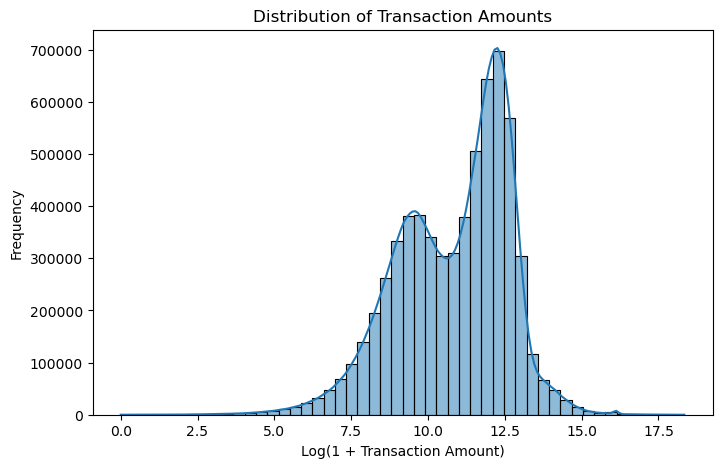

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df_clean["amount"]), bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Log(1 + Transaction Amount)")
plt.ylabel("Frequency")
plt.show()

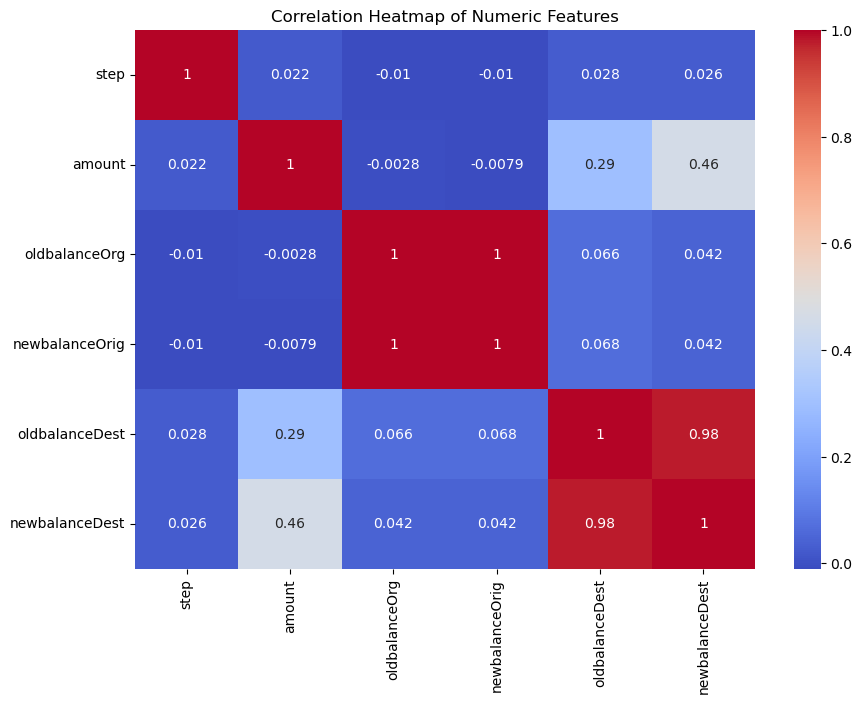

In [17]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

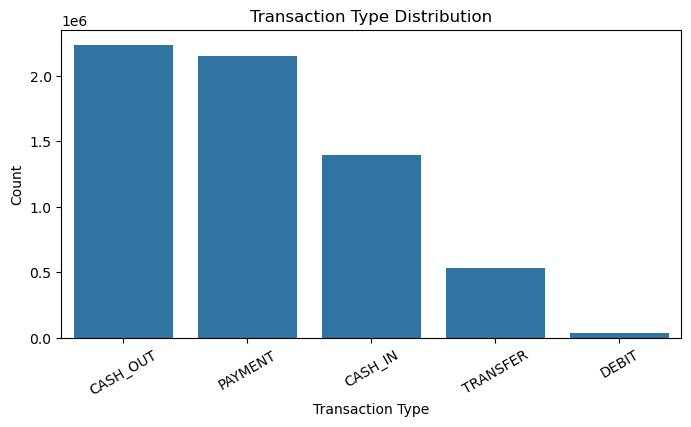

In [18]:
if "type" in df_clean.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_clean, x="type", order=df_clean["type"].value_counts().index)
    plt.title("Transaction Type Distribution")
    plt.xlabel("Transaction Type")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()

# 6. Feature Engineering

For a stronger project, the model should use customer-level behavior instead of only one transaction.

The following features are created:

- Number of transactions
- Average transaction amount
- Total transaction amount
- Maximum transaction amount
- Average old balance
- Average new balance
- Balance change
- Cash flow ratio
- Destination balance ratio
- Transaction type proportions, if transaction type exists

In [19]:
# If nameOrig exists, aggregate by customer. Otherwise, use each row as a customer.
if "nameOrig" in df_clean.columns:
    customer_id_col = "nameOrig"
else:
    customer_id_col = "customer_id"
    df_clean[customer_id_col] = np.arange(len(df_clean))

df_clean["origin_balance_change"] = df_clean["oldbalanceOrg"] - df_clean["newbalanceOrig"]
df_clean["dest_balance_change"] = df_clean["newbalanceDest"] - df_clean["oldbalanceDest"]

df_clean["cash_flow_ratio"] = np.where(
    df_clean["oldbalanceOrg"] > 0,
    df_clean["amount"] / df_clean["oldbalanceOrg"],
    0
)

df_clean["dest_balance_ratio"] = np.where(
    df_clean["oldbalanceDest"] > 0,
    df_clean["amount"] / df_clean["oldbalanceDest"],
    0
)

df_clean["log_amount"] = np.log1p(df_clean["amount"])
df_clean["log_cash_flow_ratio"] = np.log1p(np.clip(df_clean["cash_flow_ratio"], 0, None))

agg_dict = {
    "amount": ["count", "mean", "sum", "max", "std"],
    "oldbalanceOrg": ["mean", "max"],
    "newbalanceOrig": ["mean", "max"],
    "oldbalanceDest": ["mean"],
    "newbalanceDest": ["mean"],
    "origin_balance_change": ["mean", "sum"],
    "dest_balance_change": ["mean"],
    "cash_flow_ratio": ["mean", "max"],
    "dest_balance_ratio": ["mean"],
    "log_amount": ["mean"],
    "log_cash_flow_ratio": ["mean"]
}

customer_df = df_clean.groupby(customer_id_col).agg(agg_dict)
customer_df.columns = [
    "_".join(col).strip() for col in customer_df.columns.to_flat_index()
]
customer_df = customer_df.reset_index()

customer_df = customer_df.rename(columns={
    "amount_count": "transaction_count",
    "amount_mean": "avg_transaction_amount",
    "amount_sum": "total_transaction_amount",
    "amount_max": "max_transaction_amount",
    "amount_std": "std_transaction_amount",
    "oldbalanceOrg_mean": "avg_oldbalance_org",
    "oldbalanceOrg_max": "max_oldbalance_org",
    "newbalanceOrig_mean": "avg_newbalance_orig",
    "newbalanceOrig_max": "max_newbalance_orig",
    "oldbalanceDest_mean": "avg_oldbalance_dest",
    "newbalanceDest_mean": "avg_newbalance_dest",
    "origin_balance_change_mean": "avg_origin_balance_change",
    "origin_balance_change_sum": "total_origin_balance_change",
    "dest_balance_change_mean": "avg_dest_balance_change",
    "cash_flow_ratio_mean": "avg_cash_flow_ratio",
    "cash_flow_ratio_max": "max_cash_flow_ratio",
    "dest_balance_ratio_mean": "avg_dest_balance_ratio",
    "log_amount_mean": "avg_log_amount",
    "log_cash_flow_ratio_mean": "avg_log_cash_flow_ratio"
})

# Transaction type proportions
if "type" in df_clean.columns:
    type_counts = pd.crosstab(df_clean[customer_id_col], df_clean["type"], normalize="index")
    type_counts.columns = [f"type_ratio_{c}" for c in type_counts.columns]
    customer_df = customer_df.merge(type_counts.reset_index(), on=customer_id_col, how="left")

customer_df = customer_df.fillna(0)

print("Customer-level dataset shape:", customer_df.shape)
customer_df.head()

Customer-level dataset shape: (6353307, 25)


,nameOrig,transaction_count,avg_transaction_amount,total_transaction_amount,max_transaction_amount,std_transaction_amount,avg_oldbalance_org,max_oldbalance_org,avg_newbalance_orig,max_newbalance_orig,avg_oldbalance_dest,avg_newbalance_dest,avg_origin_balance_change,total_origin_balance_change,avg_dest_balance_change,avg_cash_flow_ratio,max_cash_flow_ratio,avg_dest_balance_ratio,avg_log_amount,avg_log_cash_flow_ratio,type_ratio_CASH_IN,type_ratio_CASH_OUT,type_ratio_DEBIT,type_ratio_PAYMENT,type_ratio_TRANSFER
0,C1000000639,1,244486.46,244486.46,244486.46,0.0,8946.00,8946.00,0.00,0.00,526950.37,771436.84,8946.00,8946.00,244486.47,27.329137,27.329137,0.463965,12.406919,3.343891,0.0,1.0,0.0,0.0,0.0
1,C1000001337,1,3170.28,3170.28,3170.28,0.0,58089.00,58089.00,54918.72,54918.72,0.00,0.00,3170.28,3170.28,0.00,0.054576,0.054576,0.000000,8.061891,0.053139,0.0,0.0,0.0,1.0,0.0
2,C1000001725,1,8424.74,8424.74,8424.74,0.0,783.00,783.00,0.00,0.00,0.00,0.00,783.00,783.00,0.00,10.759566,10.759566,0.000000,9.039047,2.464667,0.0,0.0,0.0,1.0,0.0
3,C1000002591,1,261877.19,261877.19,261877.19,0.0,7596.00,7596.00,269473.19,269473.19,1126627.70,864750.51,-261877.19,-261877.19,-261877.19,34.475670,34.475670,0.232443,12.475635,3.568847,1.0,0.0,0.0,0.0,0.0
4,C1000003372,1,20528.65,20528.65,20528.65,0.0,2302074.12,2302074.12,2322602.77,2322602.77,82696.17,62167.52,-20528.65,-20528.65,-20528.65,0.008917,0.008917,0.248242,9.929625,0.008878,1.0,0.0,0.0,0.0,0.0


# 7. Unsupervised Learning: Customer Clustering

The assignment requires clustering. Here, clustering is used to group customers into risk segments.

We compare:

1. K-Means Clustering
2. Gaussian Mixture Model
3. Agglomerative Clustering

The clustering methods are evaluated using:

- Silhouette Score: higher is better
- Calinski-Harabasz Score: higher is better
- Davies-Bouldin Score: lower is better

In [20]:
cluster_features = [
    "transaction_count",
    "avg_transaction_amount",
    "total_transaction_amount",
    "max_transaction_amount",
    "std_transaction_amount",
    "avg_oldbalance_org",
    "avg_newbalance_orig",
    "avg_origin_balance_change",
    "avg_cash_flow_ratio",
    "max_cash_flow_ratio",
    "avg_log_amount",
    "avg_log_cash_flow_ratio"
]

# Keept only columns that exist in customer_df
cluster_features = [c for c in cluster_features if c in customer_df.columns]

# Used only 10,000 rows to reduce running time
SAMPLE_SIZE = 10000

if len(customer_df) > SAMPLE_SIZE:
    customer_df = customer_df.sample(
        n=SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)
else:
    customer_df = customer_df.reset_index(drop=True)

print("Rows used for clustering:", len(customer_df))

# Preparing clustering data
X_cluster = customer_df[cluster_features].replace(
    [np.inf, -np.inf], np.nan
).fillna(0)

# Scaling  the data
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

clustering_results = []

# 1. K-MEANS CLUSTERING

kmeans = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_cluster_scaled)

clustering_results.append({
    "Clustering Method": "K-Means",
    "Silhouette Score": silhouette_score(X_cluster_scaled, kmeans_labels),
    "Calinski-Harabasz Score": calinski_harabasz_score(X_cluster_scaled, kmeans_labels),
    "Davies-Bouldin Score": davies_bouldin_score(X_cluster_scaled, kmeans_labels)
})

# 2. GAUSSIAN MIXTURE MODEL

gmm = GaussianMixture(
    n_components=3,
    random_state=RANDOM_STATE
)

gmm_labels = gmm.fit_predict(X_cluster_scaled)

clustering_results.append({
    "Clustering Method": "Gaussian Mixture Model",
    "Silhouette Score": silhouette_score(X_cluster_scaled, gmm_labels),
    "Calinski-Harabasz Score": calinski_harabasz_score(X_cluster_scaled, gmm_labels),
    "Davies-Bouldin Score": davies_bouldin_score(X_cluster_scaled, gmm_labels)
})

# 3. AGGLOMERATIVE CLUSTERING

agg = AgglomerativeClustering(n_clusters=3)

agg_labels = agg.fit_predict(X_cluster_scaled)

clustering_results.append({
    "Clustering Method": "Agglomerative Clustering",
    "Silhouette Score": silhouette_score(X_cluster_scaled, agg_labels),
    "Calinski-Harabasz Score": calinski_harabasz_score(X_cluster_scaled, agg_labels),
    "Davies-Bouldin Score": davies_bouldin_score(X_cluster_scaled, agg_labels)
})

# DISPLAY CLUSTERING RESULTS


clustering_results_df = pd.DataFrame(clustering_results)

clustering_results_df = clustering_results_df.sort_values(
    by=["Silhouette Score", "Davies-Bouldin Score"],
    ascending=[False, True]
)

display(clustering_results_df)

Rows used for clustering: 10000


,Clustering Method,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,Agglomerative Clustering,0.933892,2045.415351,0.148239
0,K-Means,0.923181,2202.544935,0.363196
1,Gaussian Mixture Model,0.599694,1532.784024,1.076450


In [21]:
# Select the best clustering method mainly using Silhouette Score.
best_cluster_method = clustering_results_df.sort_values(
    by=["Silhouette Score", "Davies-Bouldin Score"],
    ascending=[False, True]
).iloc[0]["Clustering Method"]

print("Best clustering method:", best_cluster_method)

if best_cluster_method == "K-Means":
    customer_df["cluster"] = kmeans_labels
elif best_cluster_method == "Gaussian Mixture Model":
    customer_df["cluster"] = gmm_labels
else:
    customer_df["cluster"] = agg_labels

customer_df["cluster"].value_counts()

Best clustering method: Agglomerative Clustering


cluster
0    9990
2       9
1       1
Name: count, dtype: int64

# 8. Cluster Profiling and Risk Interpretation

We now interpret the clusters. The cluster with the highest average cash-flow pressure and highest transaction amount pressure is treated as the highest risk group.

In [22]:
cluster_profile = customer_df.groupby("cluster")[cluster_features].mean()
cluster_profile

,transaction_count,avg_transaction_amount,total_transaction_amount,max_transaction_amount,std_transaction_amount,avg_oldbalance_org,avg_newbalance_orig,avg_origin_balance_change,avg_cash_flow_ratio,max_cash_flow_ratio,avg_log_amount,avg_log_cash_flow_ratio
cluster,,,,,,,,,,,,
0,1.000901,1.601026e+05,1.602737e+05,1.602419e+05,196.99647,865026.502411,886121.106802,-21094.604391,73.157544,73.165626,10.826731,0.868363
1,1.000000,1.699339e+06,1.699339e+06,1.699339e+06,0.00000,2.000000,0.000000,2.000000,849669.445000,849669.445000,14.345750,13.652604
2,1.000000,1.123896e+07,1.123896e+07,1.123896e+07,0.00000,64434.555556,0.000000,64434.555556,20.039286,20.039286,16.221080,1.348907


In [23]:
# Create a risk score for interpreting clusters.
# Higher cash flow ratio and higher transaction amount may indicate higher risk.
risk_profile = cluster_profile.copy()

risk_profile["cluster_risk_score"] = (
    risk_profile["avg_cash_flow_ratio"].rank() +
    risk_profile["max_cash_flow_ratio"].rank() +
    risk_profile["avg_transaction_amount"].rank()
)

risk_order = risk_profile["cluster_risk_score"].sort_values().index.tolist()

risk_mapping = {}
risk_names = ["Low Risk", "Medium Risk", "High Risk"]

for cluster_id, risk_name in zip(risk_order, risk_names):
    risk_mapping[cluster_id] = risk_name

customer_df["risk_group"] = customer_df["cluster"].map(risk_mapping)

print("Cluster risk mapping:")
print(risk_mapping)

display(customer_df[[customer_id_col, "cluster", "risk_group"]].head())
display(customer_df["risk_group"].value_counts())

Cluster risk mapping:
{0: 'Low Risk', 2: 'Medium Risk', 1: 'High Risk'}


,nameOrig,cluster,risk_group
0,C340825706,0,Low Risk
1,C599282414,0,Low Risk
2,C135881752,0,Low Risk
3,C1283757758,0,Low Risk
4,C474240998,0,Low Risk


risk_group
Low Risk       9990
Medium Risk       9
High Risk         1
Name: count, dtype: int64

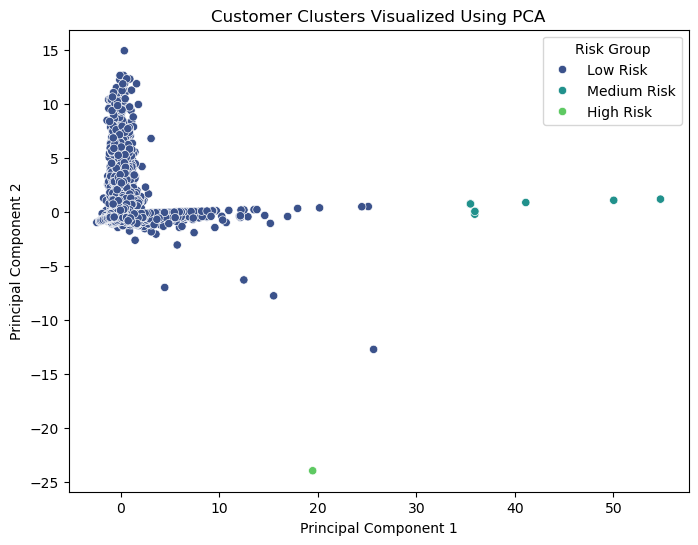

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_result = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_result[:, 0],
    y=pca_result[:, 1],
    hue=customer_df["risk_group"],
    palette="viridis"
)
plt.title("Customer Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Risk Group")
plt.show()

# 9. Create Supervised Learning Targets

## 9.1 Loan Eligibility Target

If real loan labels are not available, we create a transparent academic target.

A customer is considered eligible when they show:

- Positive balance or transaction capacity
- Reasonable cash-flow pressure
- Not in the high-risk cluster
- Transaction behavior above a minimum activity threshold

## 9.2 Loan Amount Target

The eligible loan amount is estimated using financial behavior and capped to avoid unrealistic values.

For a Uganda mobile money context, we use a small starting amount and a maximum academic cap.

In [25]:
# Adaptive thresholds make the notebook work even when many customers have only one transaction.
transaction_threshold = max(1, int(customer_df["transaction_count"].quantile(0.25)))
balance_threshold = customer_df["avg_oldbalance_org"].quantile(0.25)
cash_flow_threshold = customer_df["avg_cash_flow_ratio"].replace([np.inf, -np.inf], np.nan).fillna(0).quantile(0.75)

print("Transaction threshold:", transaction_threshold)
print("Balance threshold:", balance_threshold)
print("Cash-flow threshold:", cash_flow_threshold)

customer_df["is_eligible"] = (
    (customer_df["transaction_count"] >= transaction_threshold) &
    (customer_df["avg_oldbalance_org"] >= balance_threshold) &
    (customer_df["avg_cash_flow_ratio"] <= cash_flow_threshold) &
    (customer_df["risk_group"] != "High Risk")
).astype(int)

# If one class is missing, relax the condition slightly to avoid model failure.
if customer_df["is_eligible"].nunique() < 2:
    customer_df["is_eligible"] = (
        (customer_df["avg_oldbalance_org"] >= customer_df["avg_oldbalance_org"].median()) &
        (customer_df["risk_group"] != "High Risk")
    ).astype(int)

if customer_df["is_eligible"].nunique() < 2:
    customer_df["is_eligible"] = (
        customer_df["avg_oldbalance_org"] >= customer_df["avg_oldbalance_org"].median()
    ).astype(int)

print(customer_df["is_eligible"].value_counts())
customer_df[[customer_id_col, "risk_group", "is_eligible"]].head()

Transaction threshold: 1
Balance threshold: 0.0
Cash-flow threshold: 2.226936209493451
is_eligible
1    7500
0    2500
Name: count, dtype: int64


,nameOrig,risk_group,is_eligible
0,C340825706,Low Risk,1
1,C599282414,Low Risk,1
2,C135881752,Low Risk,1
3,C1283757758,Low Risk,1
4,C474240998,Low Risk,1


In [26]:
# Loan amount target.
# Starting amount is set at UGX 2,000 for eligible customers.
# The upper cap is UGX 500,000 for academic demonstration.
START_AMOUNT = 2000
MAX_LOAN_AMOUNT = 500000

capacity_component = 0.15 * customer_df["avg_oldbalance_org"]
activity_component = 0.05 * customer_df["total_transaction_amount"]
stability_component = 0.10 * customer_df["avg_newbalance_orig"]

raw_loan_amount = START_AMOUNT + capacity_component + activity_component + stability_component

# Penalize by risk group.
risk_multiplier = customer_df["risk_group"].map({
    "Low Risk": 1.00,
    "Medium Risk": 0.65,
    "High Risk": 0.00
}).fillna(0.50)

customer_df["eligible_loan_amount"] = np.where(
    customer_df["is_eligible"] == 1,
    raw_loan_amount * risk_multiplier,
    0
)

customer_df["eligible_loan_amount"] = customer_df["eligible_loan_amount"].clip(
    lower=0,
    upper=MAX_LOAN_AMOUNT
).round(0)

customer_df[[customer_id_col, "risk_group", "is_eligible", "eligible_loan_amount"]].head()

,nameOrig,risk_group,is_eligible,eligible_loan_amount
0,C340825706,Low Risk,1,7017.0
1,C599282414,Low Risk,1,9256.0
2,C135881752,Low Risk,1,22528.0
3,C1283757758,Low Risk,1,28783.0
4,C474240998,Low Risk,1,21824.0


# 10. Prepare Data for Supervised Learning

We include the cluster and risk group as model features because they summarize customer behavior from unsupervised learning.

In [27]:
model_df = customer_df.copy()

# Encode risk group manually.
risk_group_map_numeric = {
    "Low Risk": 0,
    "Medium Risk": 1,
    "High Risk": 2
}

model_df["risk_group_encoded"] = model_df["risk_group"].map(risk_group_map_numeric).fillna(1)

supervised_features = [
    "transaction_count",
    "avg_transaction_amount",
    "total_transaction_amount",
    "max_transaction_amount",
    "std_transaction_amount",
    "avg_oldbalance_org",
    "max_oldbalance_org",
    "avg_newbalance_orig",
    "max_newbalance_orig",
    "avg_oldbalance_dest",
    "avg_newbalance_dest",
    "avg_origin_balance_change",
    "total_origin_balance_change",
    "avg_dest_balance_change",
    "avg_cash_flow_ratio",
    "max_cash_flow_ratio",
    "avg_dest_balance_ratio",
    "avg_log_amount",
    "avg_log_cash_flow_ratio",
    "cluster",
    "risk_group_encoded"
]

# Add transaction type ratio columns if available.
type_ratio_cols = [c for c in model_df.columns if c.startswith("type_ratio_")]
supervised_features += type_ratio_cols

supervised_features = [c for c in supervised_features if c in model_df.columns]

X = model_df[supervised_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y_class = model_df["is_eligible"]

print("Number of supervised features:", len(supervised_features))
print(supervised_features)
print("\nClass distribution:")
print(y_class.value_counts())

Number of supervised features: 26
['transaction_count', 'avg_transaction_amount', 'total_transaction_amount', 'max_transaction_amount', 'std_transaction_amount', 'avg_oldbalance_org', 'max_oldbalance_org', 'avg_newbalance_orig', 'max_newbalance_orig', 'avg_oldbalance_dest', 'avg_newbalance_dest', 'avg_origin_balance_change', 'total_origin_balance_change', 'avg_dest_balance_change', 'avg_cash_flow_ratio', 'max_cash_flow_ratio', 'avg_dest_balance_ratio', 'avg_log_amount', 'avg_log_cash_flow_ratio', 'cluster', 'risk_group_encoded', 'type_ratio_CASH_IN', 'type_ratio_CASH_OUT', 'type_ratio_DEBIT', 'type_ratio_PAYMENT', 'type_ratio_TRANSFER']

Class distribution:
is_eligible
1    7500
0    2500
Name: count, dtype: int64


# 11. Supervised Learning: Loan Eligibility Classification

Six classification models are trained and compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

For loan eligibility, **precision and F1 score are very important** because approving risky customers can lead to financial loss.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_class if y_class.nunique() == 2 else None
)

classification_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=RANDOM_STATE))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])
}

classification_results = []

for name, model in classification_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    auc = roc_auc_score(y_test, y_prob) if y_prob is not None and y_test.nunique() == 2 else np.nan

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": auc
    })

classification_results_df = pd.DataFrame(classification_results)
classification_results_df.sort_values(by=["F1 Score", "Precision", "ROC-AUC"], ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000
0,Logistic Regression,0.997000,0.997337,0.998667,0.998001,0.999871
4,Support Vector Machine,0.990667,0.992028,0.995556,0.993789,0.999637
5,K-Nearest Neighbors,0.989000,0.993324,0.992000,0.992662,0.997418


Best loan eligibility model: Decision Tree


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,1.0,1.0,1.0,1.0,1.0



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       750
           1       1.00      1.00      1.00      2250

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



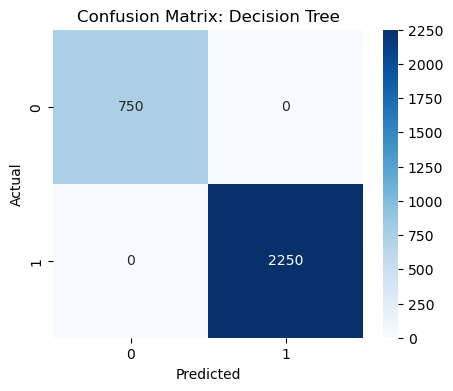

In [29]:
best_classification_row = classification_results_df.sort_values(
    by=["F1 Score", "Precision", "ROC-AUC"],
    ascending=False
).iloc[0]

best_classification_model_name = best_classification_row["Model"]
best_classification_model = classification_models[best_classification_model_name]

print("Best loan eligibility model:", best_classification_model_name)
display(best_classification_row.to_frame().T)

y_pred_best = best_classification_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_classification_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 12. Supervised Learning: Loan Amount Regression

Only eligible customers are used for loan amount prediction because ineligible customers receive UGX 0.

Six regression models are compared using:

- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error
- R² Score

For loan amount prediction, the best model should have the **lowest RMSE and MAE** and the **highest R² Score**.

In [30]:
eligible_model_df = model_df[model_df["is_eligible"] == 1].copy()

if len(eligible_model_df) < 10:
    print("Warning: Few eligible customers. Regression results may not be reliable.")

X_reg = eligible_model_df[supervised_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y_reg = eligible_model_df["eligible_loan_amount"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.30,
    random_state=RANDOM_STATE
)

regression_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNN Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ])
}

regression_results = []

for name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)

    regression_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

regression_results_df = pd.DataFrame(regression_results)
regression_results_df.sort_values(by=["RMSE", "MAE"], ascending=True)

,Model,MAE,RMSE,R2 Score
4,Gradient Boosting Regressor,875.679734,2163.748459,0.999837
3,Random Forest Regressor,541.580267,2615.713030,0.999761
2,Decision Tree Regressor,6362.737864,9465.385097,0.996874
5,KNN Regressor,4134.509244,15942.313695,0.991131
1,Ridge Regression,46715.170691,72079.729403,0.818707
0,Linear Regression,46726.106302,72079.959021,0.818706


Best loan amount prediction model: Gradient Boosting Regressor


,Model,MAE,RMSE,R2 Score
4,Gradient Boosting Regressor,875.679734,2163.748459,0.999837


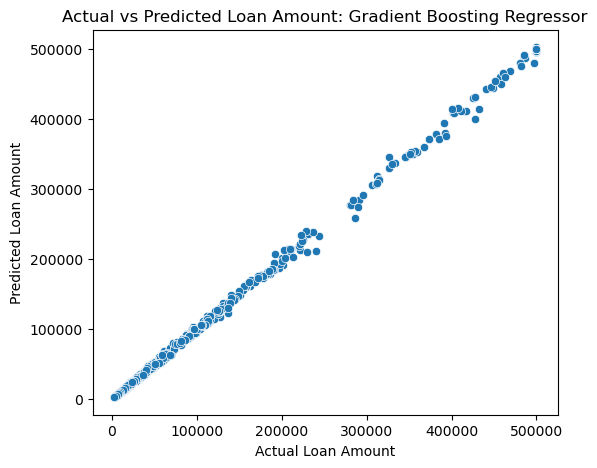

In [31]:
best_regression_row = regression_results_df.sort_values(
    by=["RMSE", "MAE"],
    ascending=True
).iloc[0]

best_regression_model_name = best_regression_row["Model"]
best_regression_model = regression_models[best_regression_model_name]

print("Best loan amount prediction model:", best_regression_model_name)
display(best_regression_row.to_frame().T)

y_pred_reg_best = best_regression_model.predict(X_test_reg)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test_reg, y=y_pred_reg_best)
plt.title(f"Actual vs Predicted Loan Amount: {best_regression_model_name}")
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.show()

# 13. Feature Importance

Tree-based models can show which features influence loan eligibility or loan amount prediction most.

This helps explain the model, which is important at master level.

Classification feature importance:


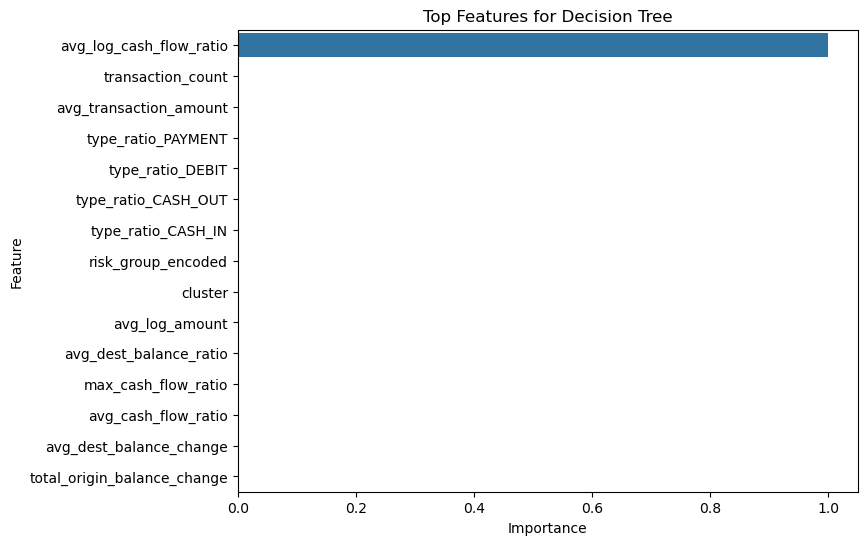

,Feature,Importance
18,avg_log_cash_flow_ratio,1.0
0,transaction_count,0.0
1,avg_transaction_amount,0.0
24,type_ratio_PAYMENT,0.0
23,type_ratio_DEBIT,0.0
22,type_ratio_CASH_OUT,0.0
21,type_ratio_CASH_IN,0.0
20,risk_group_encoded,0.0
19,cluster,0.0
17,avg_log_amount,0.0



Regression feature importance:


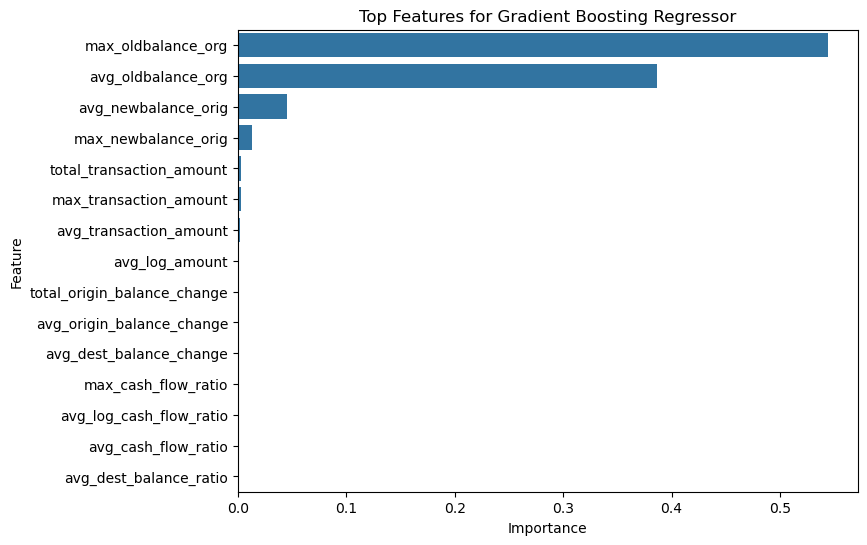

,Feature,Importance
6,max_oldbalance_org,0.544708
5,avg_oldbalance_org,0.386685
7,avg_newbalance_orig,0.045707
8,max_newbalance_orig,0.013465
2,total_transaction_amount,0.003237
3,max_transaction_amount,0.002785
1,avg_transaction_amount,0.001664
17,avg_log_amount,0.001352
12,total_origin_balance_change,0.000230
11,avg_origin_balance_change,0.000077


In [32]:
def plot_feature_importance(model, feature_names, title):
    if hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": model.feature_importances_
        }).sort_values(by="Importance", ascending=False).head(15)

        plt.figure(figsize=(8, 6))
        sns.barplot(data=importance_df, x="Importance", y="Feature")
        plt.title(title)
        plt.show()

        return importance_df
    else:
        print("This model does not provide direct feature importance.")
        return None

print("Classification feature importance:")
classification_importance = plot_feature_importance(
    best_classification_model,
    supervised_features,
    f"Top Features for {best_classification_model_name}"
)

if classification_importance is not None:
    display(classification_importance)

print("\nRegression feature importance:")
regression_importance = plot_feature_importance(
    best_regression_model,
    supervised_features,
    f"Top Features for {best_regression_model_name}"
)

if regression_importance is not None:
    display(regression_importance)

# 14. Final Prediction Function

This function gives a final loan decision for a customer already in the processed customer dataset.

In [33]:
def predict_customer_loan(customer_index):
    customer_row = model_df.iloc[[customer_index]]
    customer_features = customer_row[supervised_features].replace([np.inf, -np.inf], np.nan).fillna(0)

    eligibility_prediction = best_classification_model.predict(customer_features)[0]

    if hasattr(best_classification_model, "predict_proba"):
        eligibility_probability = best_classification_model.predict_proba(customer_features)[0][1]
    else:
        eligibility_probability = np.nan

    if eligibility_prediction == 1:
        loan_amount_prediction = best_regression_model.predict(customer_features)[0]
        loan_amount_prediction = max(START_AMOUNT, loan_amount_prediction)
        loan_amount_prediction = min(MAX_LOAN_AMOUNT, loan_amount_prediction)
    else:
        loan_amount_prediction = 0

    result = {
        "Customer ID": customer_row[customer_id_col].values[0],
        "Risk Group": customer_row["risk_group"].values[0],
        "Predicted Eligible": int(eligibility_prediction),
        "Eligibility Probability": eligibility_probability,
        "Predicted Loan Amount UGX": round(float(loan_amount_prediction), 0)
    }

    return result

# Example prediction for the first customer.
predict_customer_loan(0)

{'Customer ID': 'C340825706',
 'Risk Group': 'Low Risk',
 'Predicted Eligible': 1,
 'Eligibility Probability': np.float64(1.0),
 'Predicted Loan Amount UGX': 7346.0}

In [34]:
# Show predictions for first 10 customers.
sample_predictions = [predict_customer_loan(i) for i in range(min(10, len(model_df)))]
pd.DataFrame(sample_predictions)

,Customer ID,Risk Group,Predicted Eligible,Eligibility Probability,Predicted Loan Amount UGX
0,C340825706,Low Risk,1,1.0,7346.0
1,C599282414,Low Risk,1,1.0,8821.0
2,C135881752,Low Risk,1,1.0,22843.0
3,C1283757758,Low Risk,1,1.0,30654.0
4,C474240998,Low Risk,1,1.0,21711.0
5,C480752535,Low Risk,1,1.0,499880.0
6,C915792602,Low Risk,1,1.0,3347.0
7,C995973159,Low Risk,1,1.0,2428.0
8,C941695090,Low Risk,0,0.0,0.0
9,C1972915621,Low Risk,1,1.0,3117.0


# 15. Final Comparison Summary

In [35]:
print("=== CLUSTERING RESULTS ===")
display(clustering_results_df.sort_values(
    by=["Silhouette Score", "Davies-Bouldin Score"],
    ascending=[False, True]
))

print("\n=== CLASSIFICATION RESULTS ===")
display(classification_results_df.sort_values(
    by=["F1 Score", "Precision", "ROC-AUC"],
    ascending=False
))

print("\n=== REGRESSION RESULTS ===")
display(regression_results_df.sort_values(
    by=["RMSE", "MAE"],
    ascending=True
))

print("\nBest clustering method:", best_cluster_method)
print("Best eligibility classification model:", best_classification_model_name)
print("Best loan amount regression model:", best_regression_model_name)

=== CLUSTERING RESULTS ===


,Clustering Method,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,Agglomerative Clustering,0.933892,2045.415351,0.148239
0,K-Means,0.923181,2202.544935,0.363196
1,Gaussian Mixture Model,0.599694,1532.784024,1.076450



=== CLASSIFICATION RESULTS ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000
0,Logistic Regression,0.997000,0.997337,0.998667,0.998001,0.999871
4,Support Vector Machine,0.990667,0.992028,0.995556,0.993789,0.999637
5,K-Nearest Neighbors,0.989000,0.993324,0.992000,0.992662,0.997418



=== REGRESSION RESULTS ===


,Model,MAE,RMSE,R2 Score
4,Gradient Boosting Regressor,875.679734,2163.748459,0.999837
3,Random Forest Regressor,541.580267,2615.713030,0.999761
2,Decision Tree Regressor,6362.737864,9465.385097,0.996874
5,KNN Regressor,4134.509244,15942.313695,0.991131
1,Ridge Regression,46715.170691,72079.729403,0.818707
0,Linear Regression,46726.106302,72079.959021,0.818706



Best clustering method: Agglomerative Clustering
Best eligibility classification model: Decision Tree
Best loan amount regression model: Gradient Boosting Regressor


# 16. Discussion of Results

The clustering stage grouped customers into low-risk, medium-risk, and high-risk categories based on transaction behavior and balance patterns. The best clustering method was selected using the Silhouette Score, Calinski-Harabasz Score, and Davies-Bouldin Score.

For supervised learning, six classification models were compared for loan eligibility prediction. The best model was selected based on F1 Score, Precision, Recall, Accuracy, and ROC-AUC. In a financial credit system, precision is very important because wrongly approving risky customers may lead to loan default.

For loan amount prediction, six regression models were compared using MAE, RMSE, and R² Score. The best model was selected based on the lowest RMSE and MAE, while also considering R² Score.

The hybrid approach is stronger than using supervised learning alone because clustering provides customer risk segmentation before final loan prediction.

---

# 17. Limitations

1. If the dataset does not contain real loan repayment history, the eligibility and loan amount targets are simulated using financial rules.
2. More features such as income, savings history, repayment history, customer age, and previous loan defaults would improve accuracy.

---

# 18. Conclusion

We successfully applied both unsupervised and supervised machine learning to predict mobile money loan eligibility and eligible loan amount. Clustering was used to segment customers into risk groups, while six classification models and six regression models were compared to select the best-performing models.

The final system can support digital credit decision-making by identifying eligible customers, estimating possible loan amounts, and reducing lending risk.